(<Figure size 2000x400 with 1 Axes>,
 <Axes: ylabel='Avg. net TOA flux (W/m$^2$)'>)

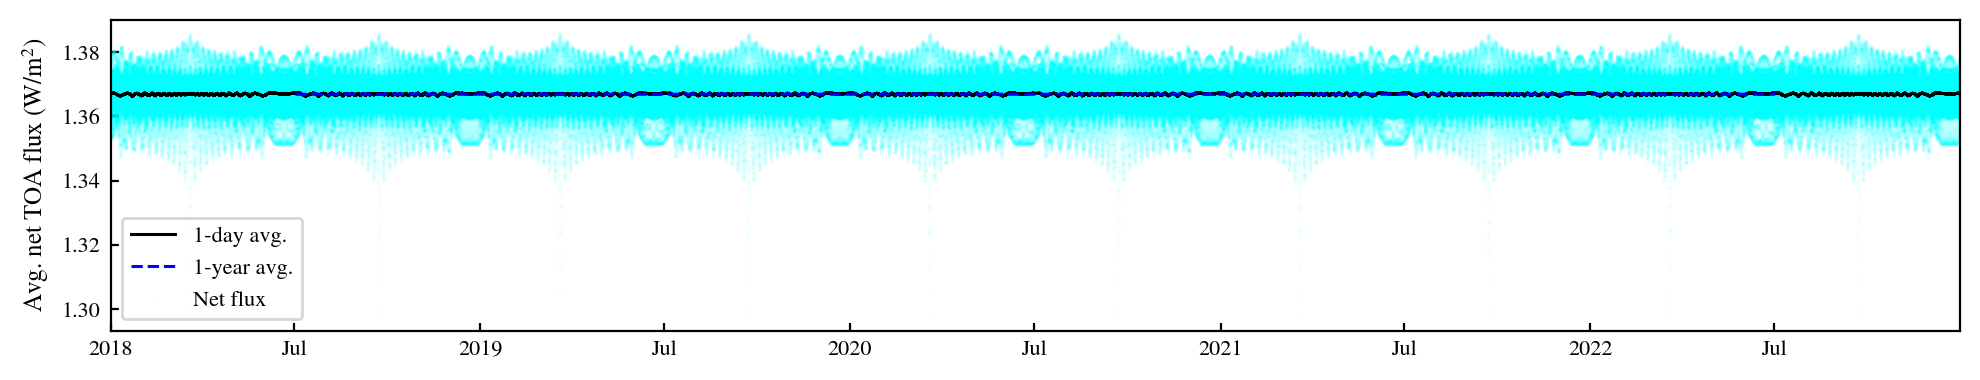

In [1]:
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, get_subdir_EEI_truth
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays
from SpaceBalls.utils import normal_smoother
from SpaceBalls.plotter import Plotter
%matplotlib inline

EEI_name = "EEI_truth_0"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))

EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name)
EEI_time_series_180x360_smooth = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=1, out_length_mode='same')

smoothing_windows_days = [1, 365] # [1, 7, 30, 365]
smoothing_windows_names = ['1-day avg.', '1-year avg.'] # ['1-day', '1-week', '1-month', '1-year']
EEI_smooth_time_series_array = [normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=window, out_length_mode='same_with_nans') for window in smoothing_windows_days]
"""
EEI_time_series_360x720 = get_true_EEI_time_series(EEI_name, 720, 360)
EEI_time_series_360x720_smooth = normal_smoother(EEI_time_series_360x720, full_jd_array, window_width_days=1, out_length_mode='same')

EEI_time_series_lebedev = get_true_EEI_time_series(EEI_name)
EEI_time_series_lebedev_smooth = normal_smoother(EEI_time_series_lebedev, full_jd_array, window_width_days=1, out_length_mode='same')
"""

EEI_smooth_dict = {window_name: EEI_smooth for (window_name, EEI_smooth) in zip(smoothing_windows_names, EEI_smooth_time_series_array)}
Plotter.plot_time_series(full_jd_array,
                        EEI_smooth_dict,
                        y_scatter_dict={'Net flux': (full_jd_array, EEI_time_series_180x360)},
                        scatter_alpha=0.03,
                        scatter_color='cyan',
                        f_width=2.5, f_height=0.5,
                        ylabel='Avg. net TOA flux (W/m$^2$)')



(<Figure size 2000x400 with 1 Axes>,
 <Axes: ylabel='Avg. net TOA flux (W/m$^2$)'>)

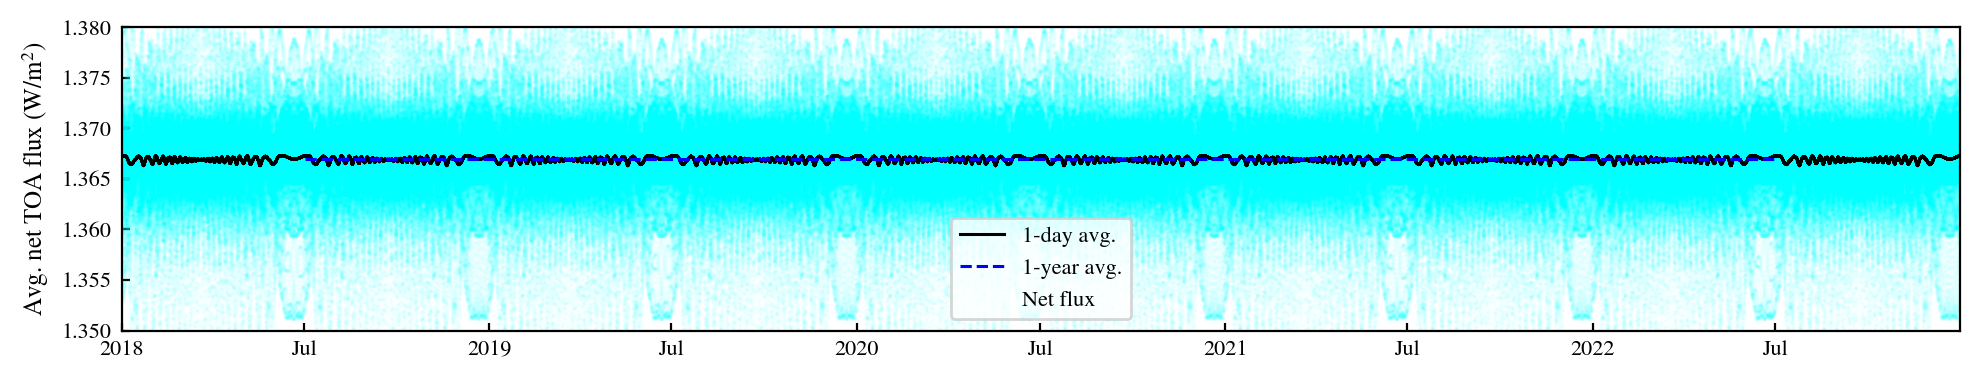

In [2]:
Plotter.plot_time_series(full_jd_array,
                        EEI_smooth_dict,
                        y_scatter_dict={'Net flux': (full_jd_array, EEI_time_series_180x360)},
                        scatter_alpha=0.03,
                        scatter_color='cyan',
                        f_width=2.5, f_height=0.5,
                        ylabel='Avg. net TOA flux (W/m$^2$)',
                        ylim=[1.35, 1.38])

In [4]:
import numpy as np
import SpaceBalls.radiation_settings as rad_settings
from SpaceBalls.radiation_fluxes_preprocessing import get_r_sun_day_hist

EEI_name = "EEI_truth_0"
rad_settings_dict = rad_settings.radiation_settings_from_EEI_truth_name(EEI_name)
import config.constants as constants
from astropy.time import Time

AU = constants.astronomical_unit()
RE = constants.earth_radius()

mid_day_jd_array = np.round(np.mean(get_EEI_truth_daily_jd_arrays(EEI_name), axis=1))
approx_EEI_array = np.zeros_like(mid_day_jd_array)

for i, jD in enumerate(mid_day_jd_array[:300]):
    TSI_1AU = rad_settings.get_TSI_1AU(jD, rad_settings_dict["TSI_source"])
    r_sun_day = get_r_sun_day_hist(rad_settings_dict["ephemerides"], jD)
    d_sun_avg = np.mean(np.linalg.norm(r_sun_day, axis=1))
    TSI_earth = TSI_1AU * (AU / d_sun_avg) **2

    datestr = Time(jD, format='jd').to_datetime().strftime("%Y-%m-%d")
    a_sh_map, e_sh_map = rad_settings.get_ae_sh_maps_numpy_new(rad_settings_dict["sh_mode"], datestr)
    c00_a = a_sh_map[0,0,0]
    c00_e = e_sh_map[0,0,0]
    print(f"C00_a = {c00_a}; C00_e = {c00_e}")
    print(f"(1-C00_a-C00_e) = {(1 - c00_a - c00_e)*100}%")
    approx_EEI_day = TSI_earth/4 * (1 - c00_a - c00_e) 
    print(f"TSI * (1-C00_a-C00_e) = {approx_EEI_day}")
    approx_EEI_array[i] = approx_EEI_day

C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e = 0.696
(1-C00_a-C00_e) = 0.40000000000000036%
TSI * (1-C00_a-C00_e) = 1.3610876539626684
C00_a = 0.3; C00_e 

(<Figure size 2000x400 with 1 Axes>,
 <Axes: ylabel='Avg. net TOA flux (W/m$^2$)'>)

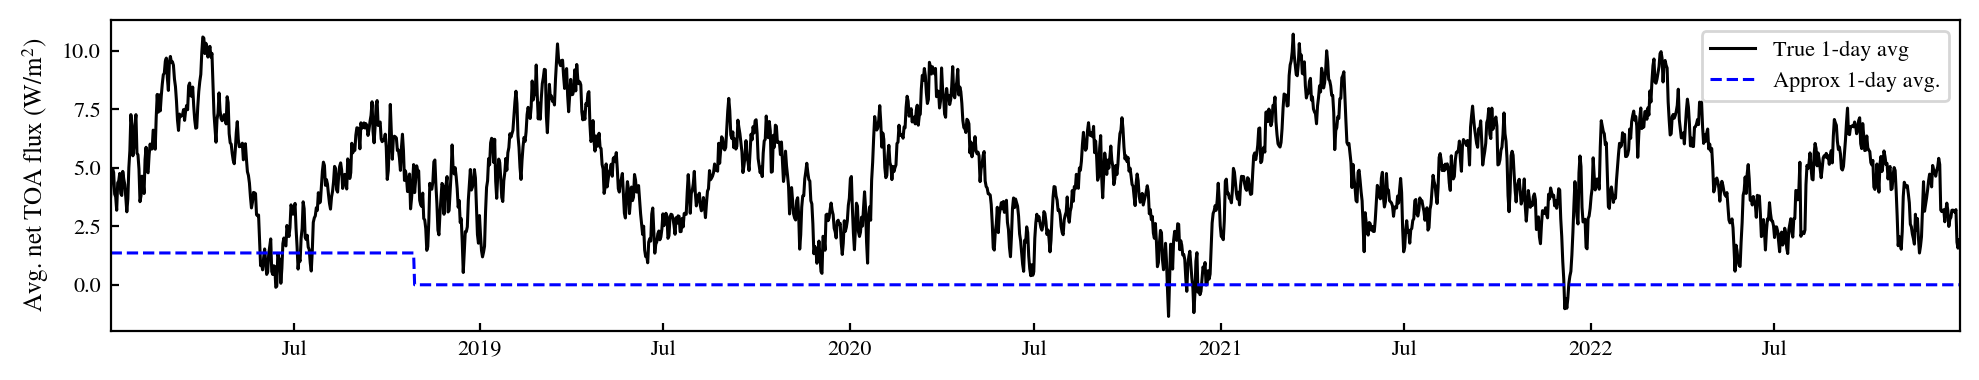

In [5]:
true_EEI_day_array = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_time_series_array[0])
Plotter.plot_time_series(mid_day_jd_array,
                        {'True 1-day avg': true_EEI_day_array,
                         'Approx 1-day avg.': approx_EEI_array},
                        f_width=2.5, f_height=0.5,
                        ylabel='Avg. net TOA flux (W/m$^2$)')

In [ ]:

Plotter.plot_time_series(full_jd_array,
                         {'1-day avg. EEI': EEI_time_series_180x360_smooth},
                          f_width=2.5, f_height=0.5,
                          ylabel='Avg. net TOA flux (W/m$^2$)',
                          y_scatter_dict={'$\phi(t)$ (W/m$^2$)': (full_jd_array,EEI_time_series_180x360)},
                          scatter_alpha=0.007)

Plotter.plot_time_series(full_jd_array,
                         {'1-day avg. EEI (180x360 grid)': EEI_time_series_180x360_smooth,
                          '1-day avg. EEI (360x720 grid)': EEI_time_series_360x720_smooth},
                          f_width=2, f_height=0.7,
                          ylabel='Avg. net TOA flux (W/m$^2$)')

Plotter.plot_time_series(full_jd_array,
                         {'Diff. between 180x360 and 360x720 grid': EEI_time_series_180x360_smooth - EEI_time_series_360x720_smooth,
                          'Diff between 180x360 and Lebedev grid': EEI_time_series_180x360_smooth - EEI_time_series_lebedev_smooth,
                          'Diff between 360x720 and Lebedev grid': EEI_time_series_360x720_smooth - EEI_time_series_lebedev_smooth},
                          f_width=2, f_height=0.7,
                          ylabel='Diff. in avg. net TOA flux (W/m$^2$)')

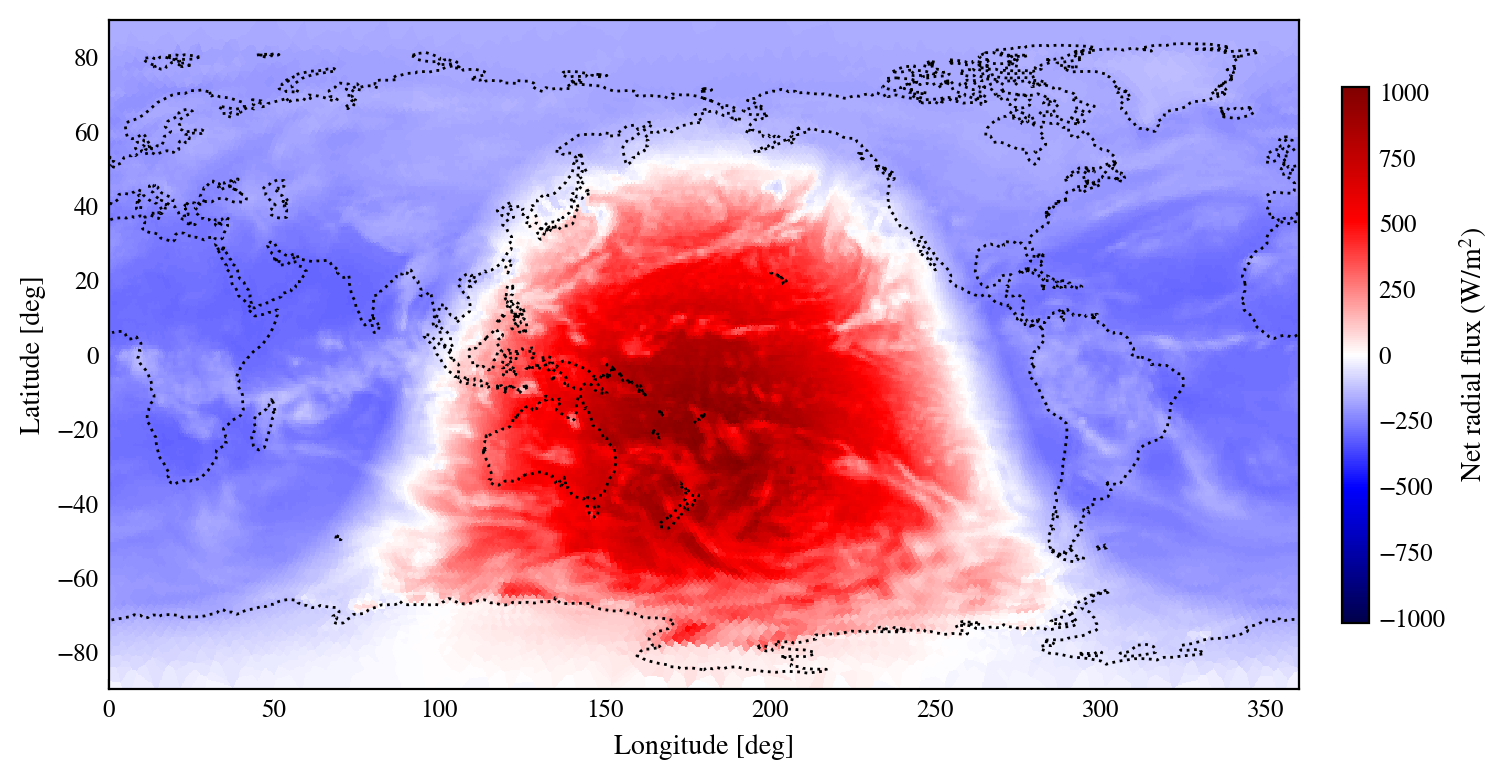

In [6]:
import numpy as np
import os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, get_subdir_EEI_truth
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid
from SpaceBalls.paths import MEDIA_DIR

grid = QuadratureGrid(alt_km=0, order=325)
toa_subdir = get_subdir_EEI_truth("EEI_truth_2", 'daily_hist_net_toa', grid_name=grid.grid_name)
day_0 = np.load(os.path.join(toa_subdir, 'day_0.npy'))

Plotter.plot_geo_data_new(day_0[:,0], grid, data_label='Net radial flux (W/m$^2$)', 
                          make_symmetric_cmap=True)



In [ ]:
# this block was to find the bug in the computation of truth: ae sh maps had not been truncated properly!
# the effect in average net flux is still in the order of mW though

import numpy as np
import os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, get_subdir_EEI_truth
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid
from SpaceBalls.paths import MEDIA_DIR

grid = RegularLatLonGrid(alt_km=0, n_lat=180, n_lon=360)
toa_subdir = get_subdir_EEI_truth("EEI_truth_1", 'daily_hist_net_toa', n_lon=360, n_lat=180)

# grid 180x360: net toa: day_0b.txt is correct; day_0.npy si just corrected; all others are bugged
            #   emission_toa: day_0.npy is just corrected; day_0b and all others are old (bugged)
bugged_subdir = os.path.join(MEDIA_DIR, 'true_EEI', "EEI_truth_1", 'grid_'+'180x360', 'bugged_toa_files',
                              'daily_hist_net_toa')

day_0_old = np.loadtxt(os.path.join(bugged_subdir, 'day_0b.txt')).reshape((180,360,1440))
#day_0_old = np.load(os.path.join(bugged_subdir, 'day_0_bugged.npy'))
day_0_new = np.load(os.path.join(toa_subdir, 'day_0.npy'))

time_series_old = grid.compute_surf_integral(day_0_old, average=True)
time_series_new = grid.compute_surf_integral(day_0_new, average=True)

Plotter.plot_geo_data(day_0_old[:,:,0], grid.lon_edges_vec, grid.lat_edges_vec)
Plotter.plot_geo_data(day_0_new[:,:,0], grid.lon_edges_vec, grid.lat_edges_vec)

Plotter.plot_geo_data(day_0_new[:,:,0]-day_0_old[:,:,0], grid.lon_edges_vec, grid.lat_edges_vec)

toa_subdir_SFF = get_subdir_EEI_truth("EEI_truth_1", 'daily_hist_net_toa_SFF', n_lon=360, n_lat=180)
net_toa_hist_SFF = np.load(os.path.join(toa_subdir_SFF, 'day_0.npy'))
Plotter.plot_geo_data(net_toa_hist_SFF[:,:,0], grid.lon_edges_vec, grid.lat_edges_vec)

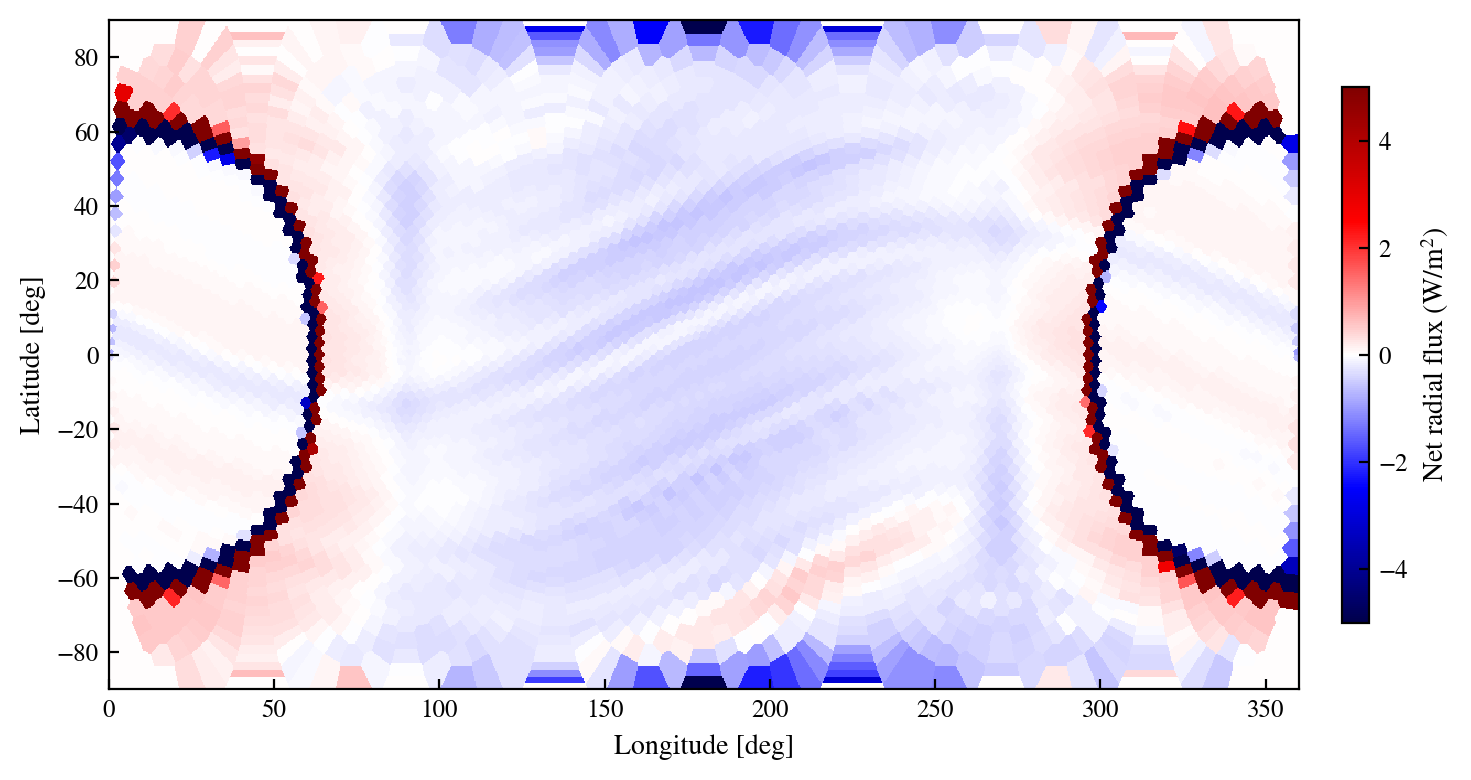

In [ ]:
# check difference between interpolated and accurate avg maps in SFF (avg)

import numpy as np
import os
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth
from SpaceBalls.paths import MEDIA_DIR

day_idx = 270
grid_quad = QuadratureGrid(alt_km=0, order=131)

subdir_interp = get_subdir_EEI_truth("EEI_truth_1", 'daily_avg_net_Fr_800km_SFF', grid_quad.grid_name)
avg_interp = np.load(os.path.join(subdir_interp, 'day_'+str(day_idx)+'.npy'))

subdir_acc = get_subdir_EEI_truth("EEI_truth_1", 'daily_avg_net_Fr_800km_SFF_accurate', grid_quad.grid_name)
avg_acc = np.load(os.path.join(subdir_acc, 'day_'+str(day_idx)+'.npy'))

diff = avg_interp - avg_acc
Plotter.plot_geo_data_new(diff, grid_quad, data_label='Net radial flux (W/m$^2$)', max_mag=5)


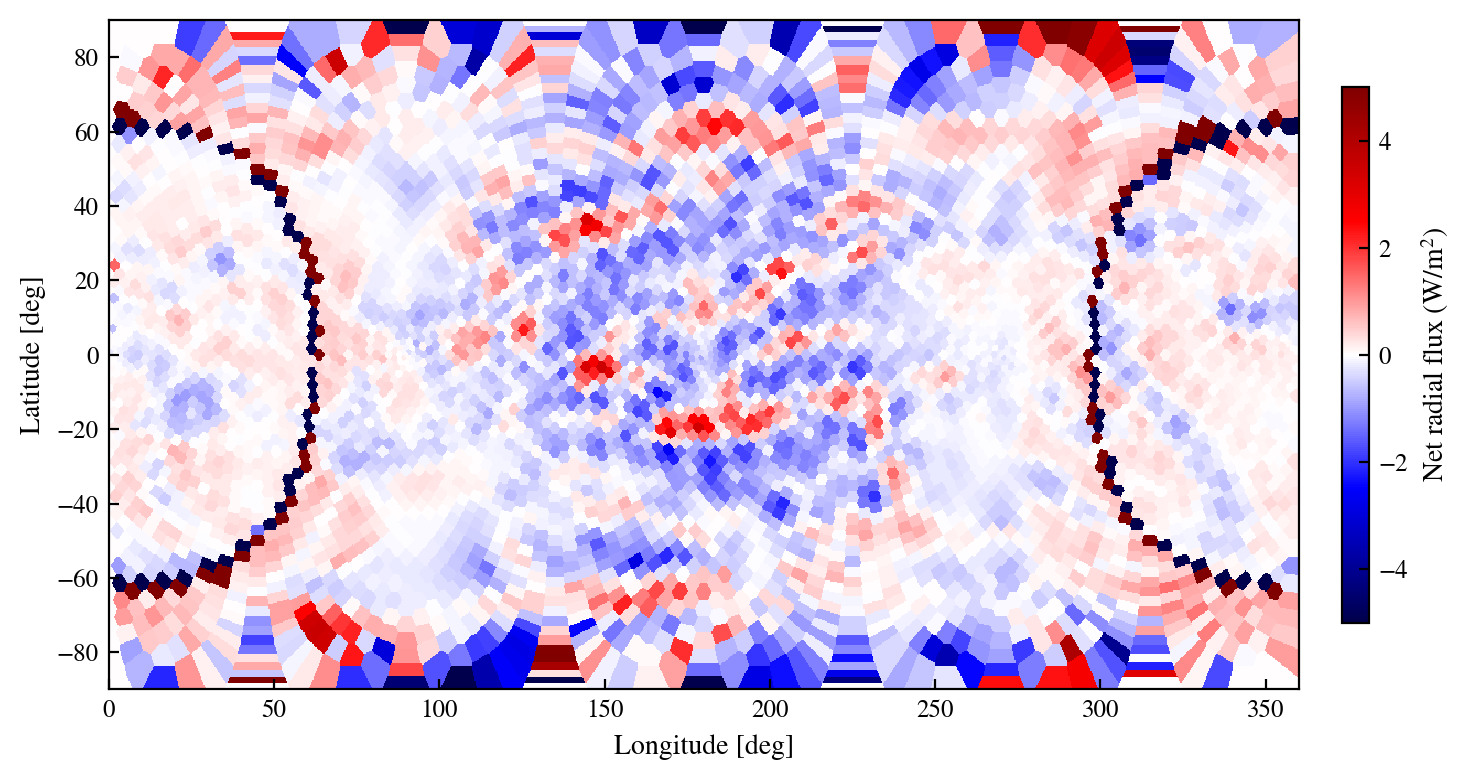

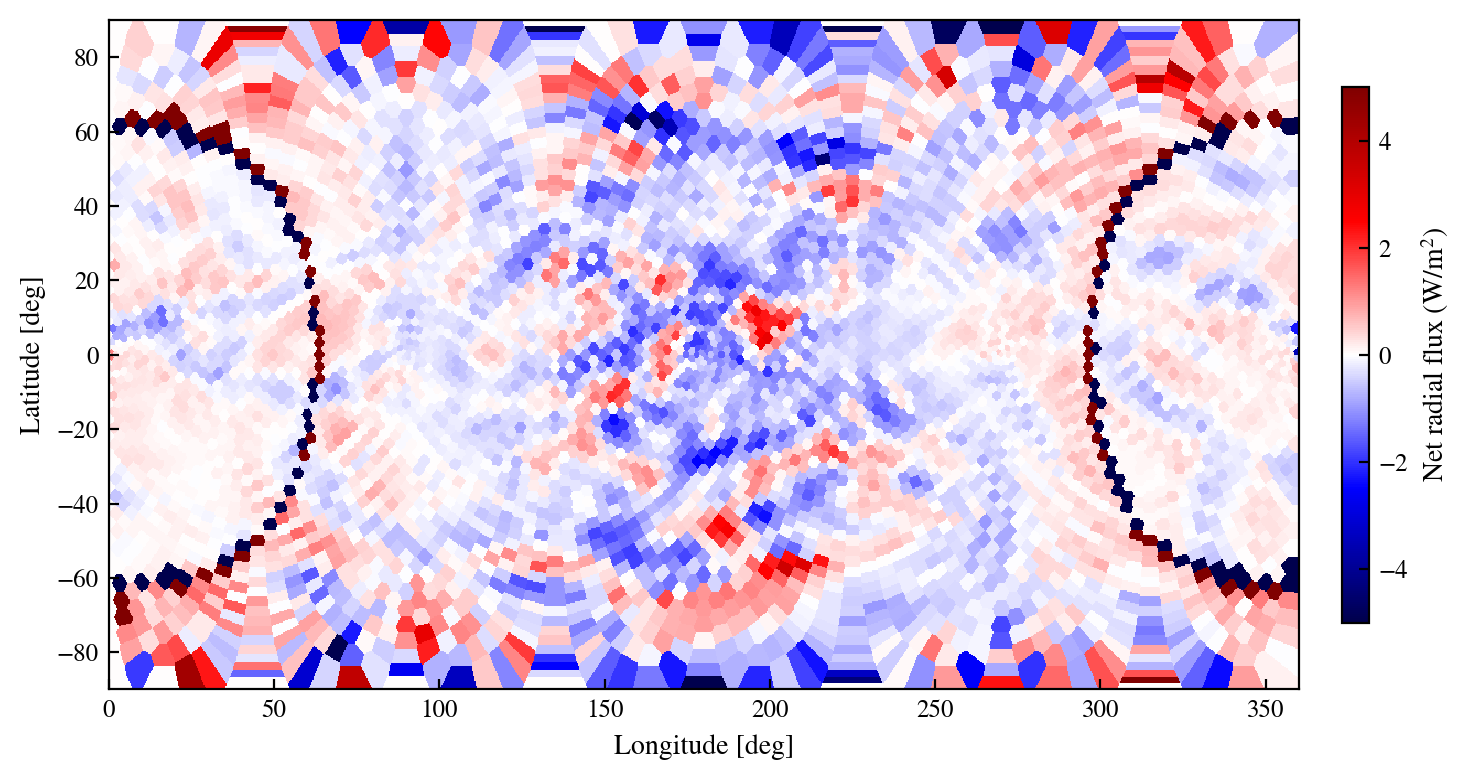

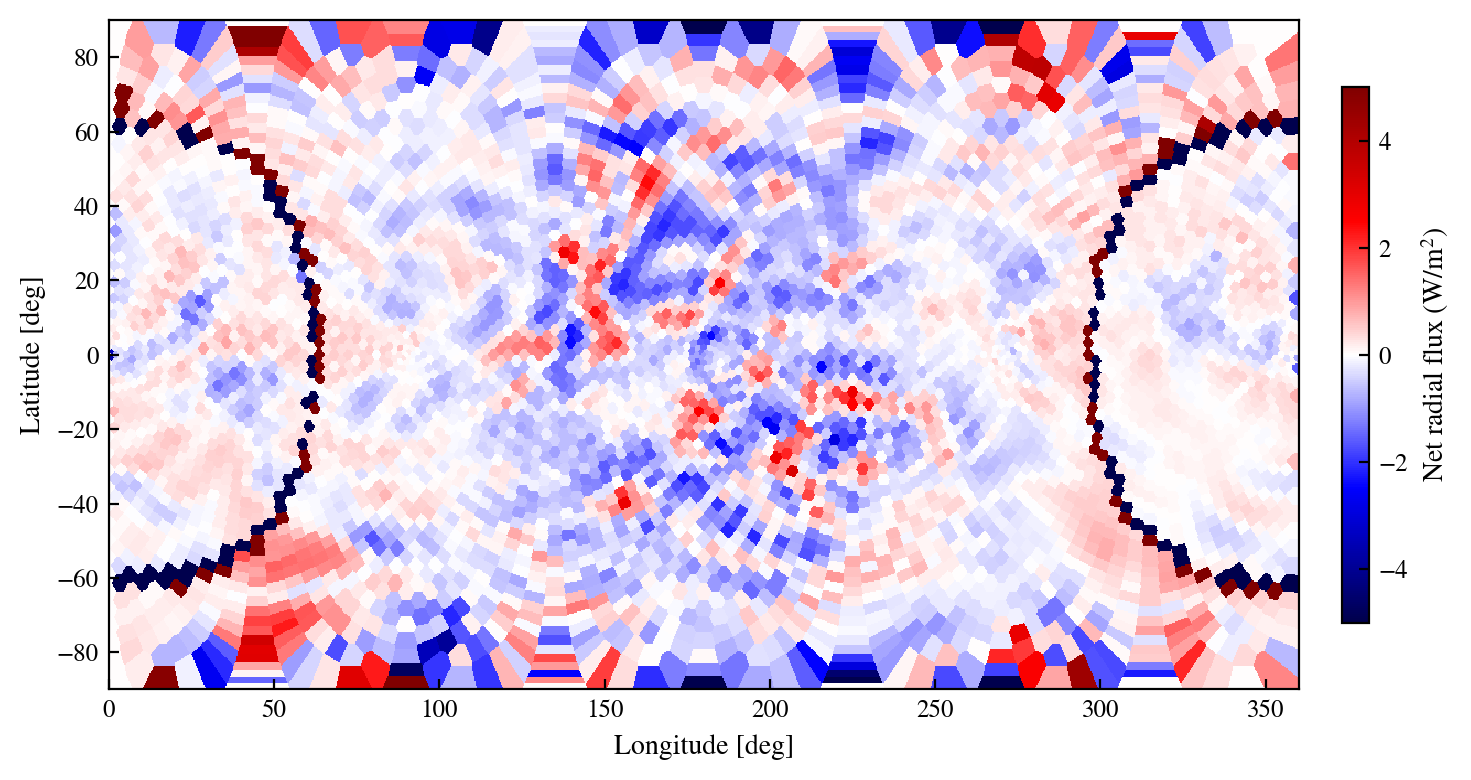

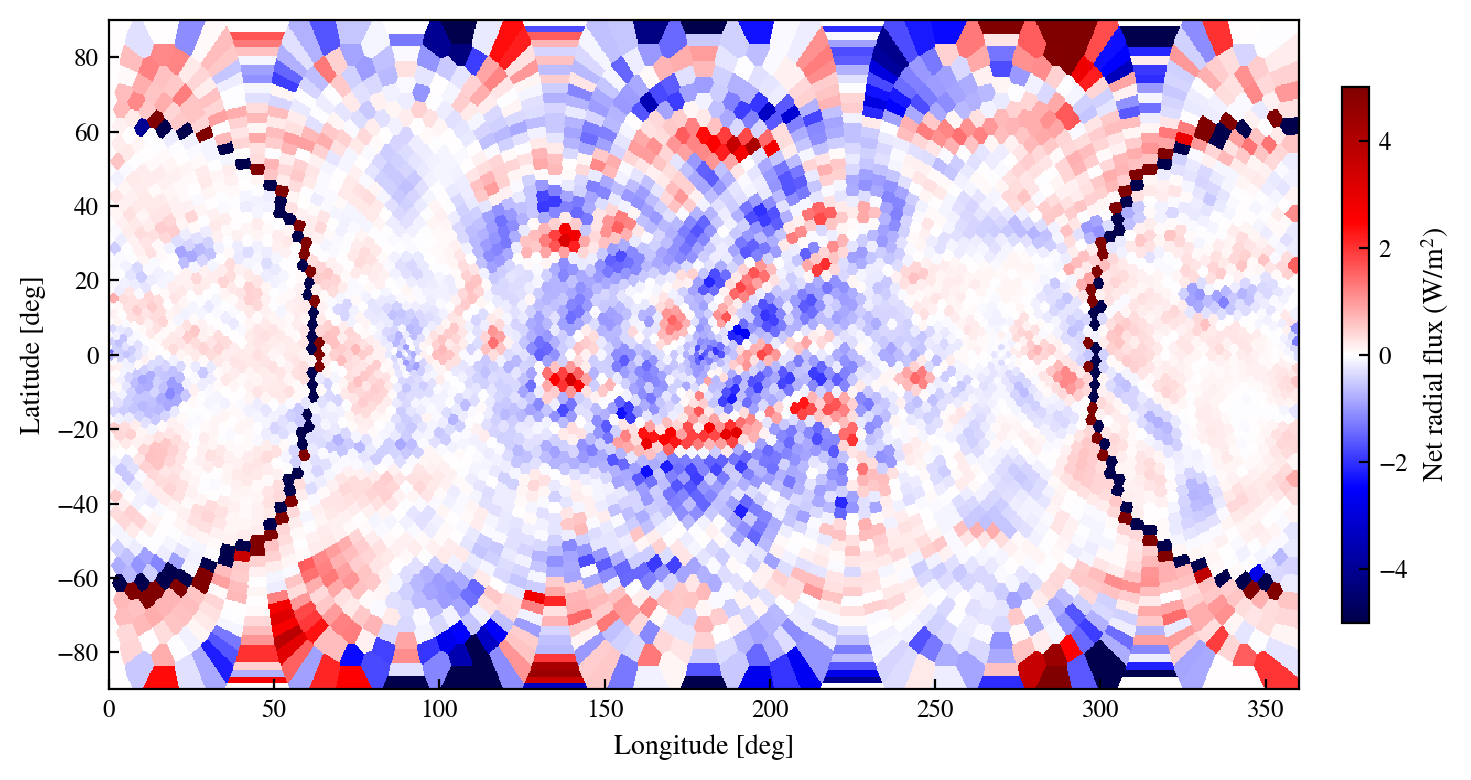

In [23]:
# check difference between interpolated and accurate avg maps in SFF (inst.)

import numpy as np
import os
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth
from SpaceBalls.paths import MEDIA_DIR

day_idx = 270
grid_quad = QuadratureGrid(alt_km=0, order=131)

subdir_interp = get_subdir_EEI_truth("EEI_truth_1", 'daily_hist_net_Fr_800km_SFF', grid_quad.grid_name)
hist_interp = np.load(os.path.join(subdir_interp, 'day_'+str(day_idx)+'.npy'))

subdir_acc = get_subdir_EEI_truth("EEI_truth_1", 'daily_hist_net_Fr_800km_SFF_accurate', grid_quad.grid_name)
hist_acc = np.load(os.path.join(subdir_acc, 'day_'+str(day_idx)+'.npy'))

diff = hist_interp - hist_acc
for i in [0, 500, 1000, 1400]:
    Plotter.plot_geo_data_new(diff[:,i], grid_quad, data_label='Net radial flux (W/m$^2$)', max_mag=5)


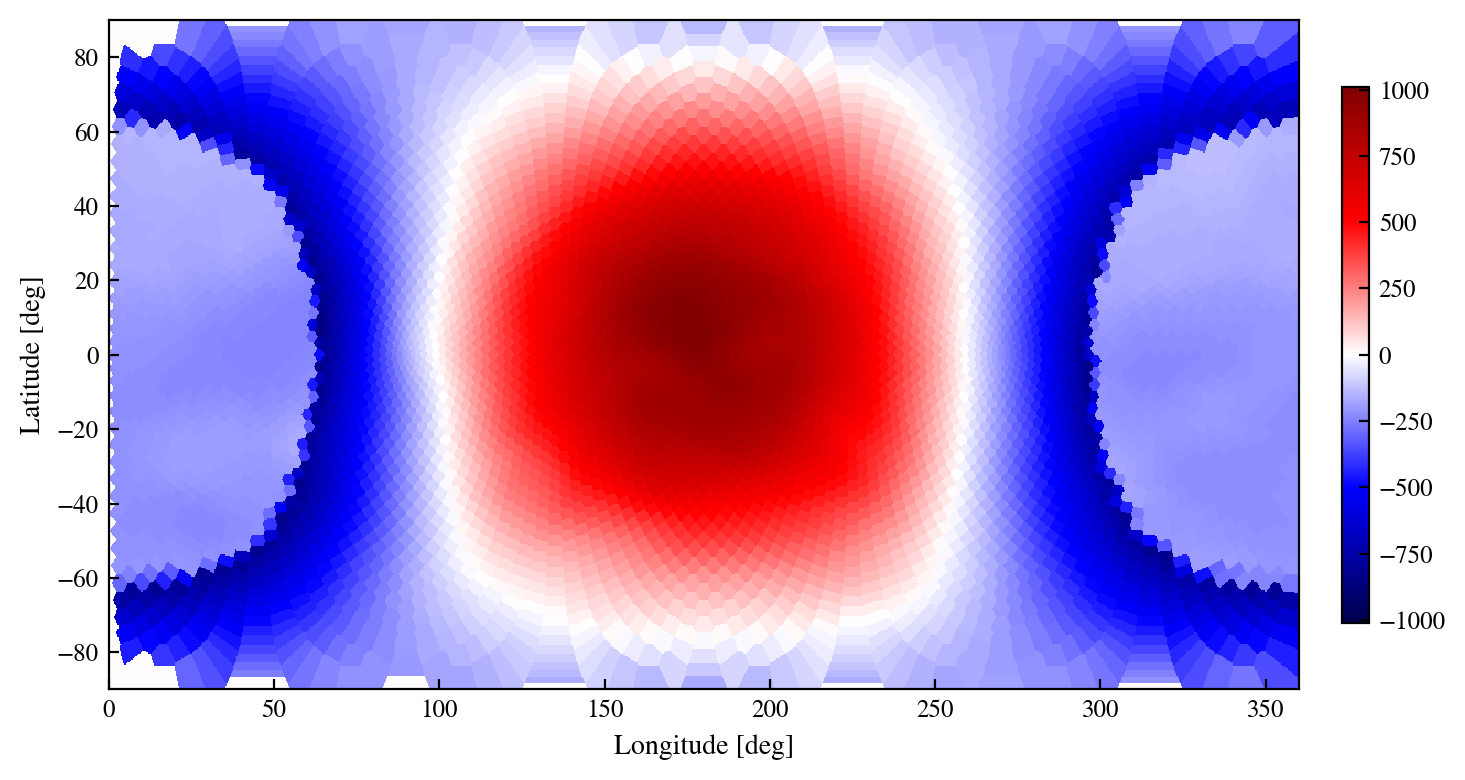

In [1]:
import numpy as np
import os
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth
from SpaceBalls.paths import MEDIA_DIR

grid_reg = RegularLatLonGrid(alt_km=0, n_lat=180, n_lon=360)
grid_quad = QuadratureGrid(alt_km=0, order=131)

for grid in [grid_quad]:
    subdir = get_subdir_EEI_truth("EEI_truth_1", 'daily_hist_net_Fr_800km_SFF', grid.grid_name)
    day_0_new = np.load(os.path.join(subdir, 'day_1.npy'))
    Plotter.plot_geo_data_new(day_0_new[...,0], grid)


In [ ]:
import numpy as np
import os
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid, sphere_field_interp
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth

grid_reg = RegularLatLonGrid(alt_km=0, n_lat=180, n_lon=360)
grid_quad = QuadratureGrid(alt_km=0, order=131)


toa_subdir = get_subdir_EEI_truth("EEI_truth_1", 'daily_hist_net_toa', grid_reg.grid_name)
day_0_reg = np.load(os.path.join(toa_subdir, 'day_0.npy'))

toa_subdir = get_subdir_EEI_truth("EEI_truth_1", 'daily_hist_net_toa', grid_quad.grid_name)
day_0_quad = np.load(os.path.join(toa_subdir, 'day_0.npy'))

for method in ["griddata_linear", "griddata_cubic"]:
    data_vec = sphere_field_interp(grid_quad.stacked_grid_latlon, day_0_quad, 
                                    grid_reg.stacked_grid_latlon,
                                    method=method)
    day_0_quad_interp = grid_reg.reshape_if_needed(data_vec)
    diff_map = day_0_quad_interp - day_0_reg

    Plotter.plot_geo_data_new(diff_map[:,:,300], grid_reg)


True avg: 4.294218696432656
True avg: 4.295678881226454
Avg. 800km 1deg: 4.337226057898994
Avg. 800km q131: 4.264811457130263
Error avg 1deg grid: 0.041547176672540154
Error avg q131 grid: 0.03086742409619081


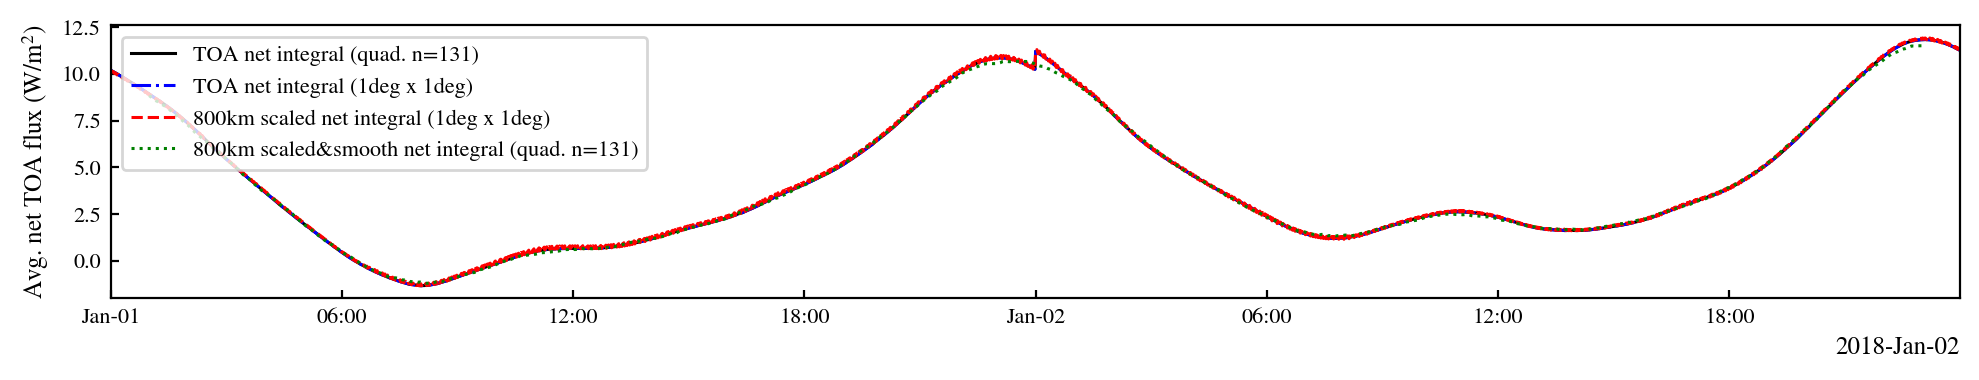

In [21]:
import numpy as np
import sys, os
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays
from SpaceBalls.sph_meshing import get_sphere_grid, get_spherical_grid_cell_areas
from SpaceBalls.utils import normal_smoother
from scipy.integrate import lebedev_rule
import config.constants as constants

EEI_name = "EEI_truth_1"
Re = constants.earth_radius()

selected_days = [0,1]

jd_array = np.concatenate([get_EEI_truth_daily_jd_arrays(EEI_name)[idx] for idx in selected_days])

# compare integral at altitude vs toa for day 0:
toa_q131_subdir = get_subdir_EEI_truth(EEI_name, 'daily_hist_net_toa_surf_avg', 'grid_quad_n131')
toa_q131 = np.concatenate([np.load(os.path.join(toa_q131_subdir, 'day_'+str(idx)+'.npy')) for idx in selected_days])

toa_1deg_subdir = get_subdir_EEI_truth(EEI_name, 'daily_hist_net_toa_surf_avg', 'grid_180x360')
toa_1deg = np.concatenate([np.load(os.path.join(toa_1deg_subdir, 'day_'+str(idx)+'.npy')) for idx in selected_days])

cv800_1deg_subdir = get_subdir_EEI_truth(EEI_name, 'daily_hist_net_Fr_800km_surf_avg', 'grid_180x360')
cv800_1deg = np.concatenate([np.load(os.path.join(cv800_1deg_subdir, 'day_'+str(idx)+'.npy')) for idx in selected_days])

cv800_q131_subdir = get_subdir_EEI_truth(EEI_name, 'daily_hist_net_Fr_800km_surf_avg', 'grid_quad_n131')
cv800_q131 = np.concatenate([np.load(os.path.join(cv800_q131_subdir, 'day_'+str(idx)+'.npy')) for idx in selected_days])

cv800_q131_smooth = normal_smoother(cv800_q131, jd_array, 2/24, out_length_mode='same_with_nans')

Plotter.plot_time_series(jd_array,
                         {'TOA net integral (quad. n=131)': toa_q131,
                          'TOA net integral (1deg x 1deg)': toa_1deg,
                          '800km scaled net integral (1deg x 1deg)': cv800_1deg,
                          #'800km scaled net integral (quad. n=131)': cv800_q131,
                          '800km scaled&smooth net integral (quad. n=131)': cv800_q131_smooth,
                          },
                          f_width=2.5, f_height=0.5,
                          ylabel='Avg. net TOA flux (W/m$^2$)',
                          )

print(f"True avg: {np.mean(toa_1deg)}")
print(f"True avg: {np.mean(toa_q131)}")
print(f"Avg. 800km 1deg: {np.mean(cv800_1deg)}")
print(f"Avg. 800km q131: {np.mean(cv800_q131)}")
print(f"Error avg 1deg grid: {np.abs(np.mean(cv800_1deg) - np.mean(toa_q131))}")
print(f"Error avg q131 grid: {np.abs(np.mean(cv800_q131) - np.mean(toa_q131))}")


[████████████████████████████████████████] 100.00%


(<Figure size 2000x400 with 1 Axes>, <Axes: ylabel='TOA vs 800km net diff'>)

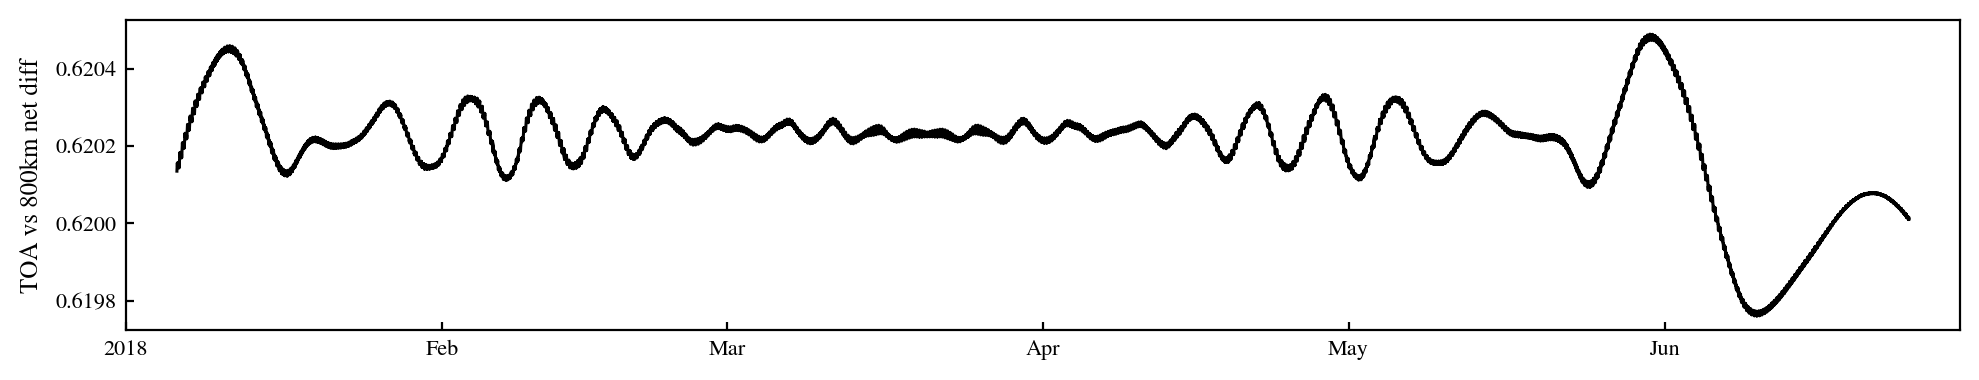

In [3]:
# checking energy conservation with SFF accurate (based on blocks below)

import numpy as np
import sys, os
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth, get_true_EEI_time_series
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.sph_meshing import QuadratureGrid, get_sphere_grid, get_spherical_grid_cell_areas
from SpaceBalls.utils import normal_smoother, progress_bar
from scipy.integrate import lebedev_rule
import config.constants as constants
from SpaceBalls.paths import MEDIA_DIR

EEI_name = "EEI_truth_0"
jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
Re = constants.earth_radius()
grid = QuadratureGrid(alt_km=800, order=131)

n_days = 180
all_daily_net = [None] * n_days

for i in range(n_days): # 1826
    progress_bar(i, n_days)
    day_net_map = np.load(os.path.join(MEDIA_DIR, 
                                                'true_EEI', 
                                                EEI_name, 
                                                'grid_quad_n131',
                                                'daily_hist_net_Fr_800km_SFF_accurate', 
                                                'day_'+str(i)+'.npy'))
    all_daily_net[i] = grid.compute_surf_integral(day_net_map, average=True)
window_days = 10

full_net_alt = np.concatenate(all_daily_net)
full_net_alt_smooth = normal_smoother(full_net_alt, jd_array, window_days, out_length_mode='same_with_nans')

EEI_true_time_series = get_true_EEI_time_series(EEI_name)
#mid_day_jd_array = get_mid_day_jd_array(EEI_name)
window_name = '1-year'
EEI_smooth_true = normal_smoother(EEI_true_time_series, jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
EEI_smooth_true = EEI_smooth_true[:(len(full_net_alt))]
#EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

Plotter.plot_time_series(jd_array[:(len(full_net_alt))],
                        {'diff': full_net_alt_smooth-EEI_smooth_true},
                        f_width=2.5, f_height=0.5,
                        ylabel='TOA vs 800km net diff',
                        #title=f"Error RMS: {nanrms(error)}"
                        )

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

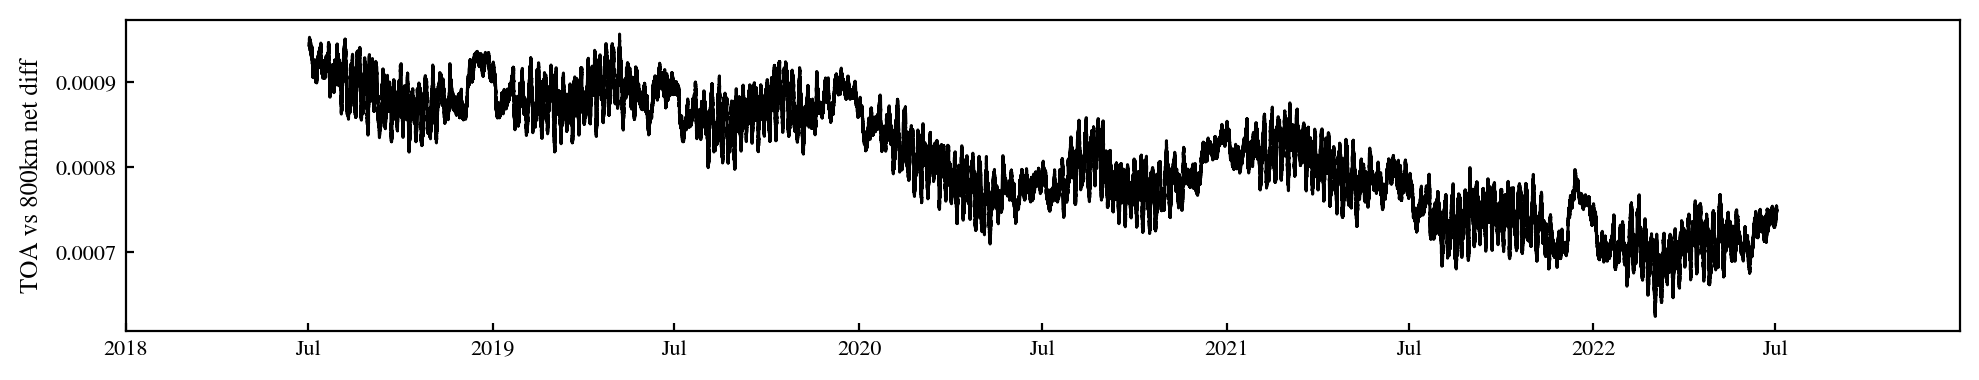

In [7]:
import numpy as np
import sys, os
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth, get_true_EEI_time_series
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.sph_meshing import get_sphere_grid, get_spherical_grid_cell_areas
from SpaceBalls.utils import normal_smoother
from scipy.integrate import lebedev_rule
import config.constants as constants
from SpaceBalls.paths import MEDIA_DIR

EEI_name = "EEI_truth_1"
jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
Re = constants.earth_radius()

all_daily_net = [None] * 1826

for i in range(1826):
    print(i)
    all_daily_net[i] = np.load(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, 'grid_quad_n131',
                                            'daily_hist_net_Fr_800km_surf_avg', 'day_'+str(i)+'.npy'))

full_net_alt = np.concatenate(all_daily_net)
full_net_alt_smooth = normal_smoother(full_net_alt, jd_array, 365, out_length_mode='same_with_nans')

EEI_true_time_series = get_true_EEI_time_series(EEI_name)
#mid_day_jd_array = get_mid_day_jd_array(EEI_name)
window_days = 365
window_name = '1-year'
EEI_smooth_true = normal_smoother(EEI_true_time_series, jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
#EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

Plotter.plot_time_series(jd_array,
                        {'diff': full_net_alt_smooth-EEI_smooth_true},
                        f_width=2.5, f_height=0.5,
                        ylabel='TOA vs 800km net diff',
                        #title=f"Error RMS: {nanrms(error)}"
                        )

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

(<Figure size 2000x400 with 1 Axes>, <Axes: ylabel='TOA vs 800km net diff'>)

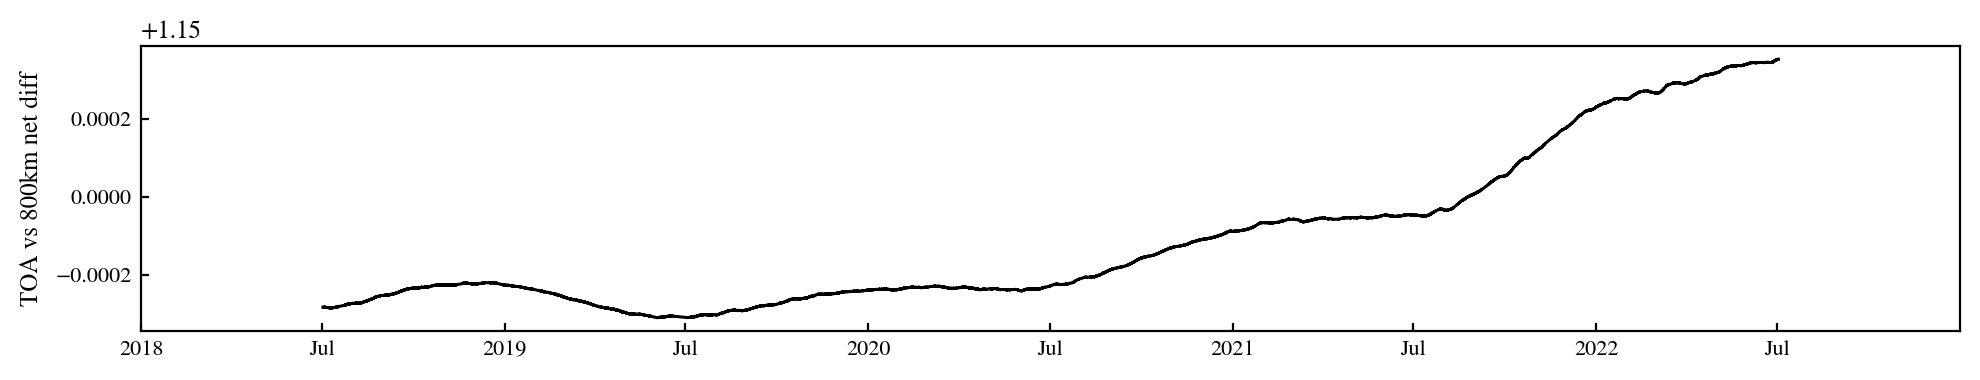

In [2]:
import numpy as np
import sys, os
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import get_subdir_EEI_truth, get_true_EEI_time_series
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.sph_meshing import get_sphere_grid, get_spherical_grid_cell_areas, QuadratureGrid
from SpaceBalls.utils import normal_smoother
from scipy.integrate import lebedev_rule
import config.constants as constants
RE = constants.earth_radius()
from SpaceBalls.paths import MEDIA_DIR

EEI_name = "EEI_truth_1"
jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
Re = constants.earth_radius()

all_daily_net = [None] * 1826
grid = QuadratureGrid(alt_km=800, order=131)

for i in range(1826):
    print(i)
    daily_hist = np.load(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, 'grid_quad_n131',
                                            'daily_hist_net_Fr_800km_SFF_accurate', 'day_'+str(i)+'.npy'))
    all_daily_net[i] = grid.compute_surf_integral(daily_hist) / (4*np.pi*RE**2)

full_net_alt = np.concatenate(all_daily_net)
full_net_alt_smooth = normal_smoother(full_net_alt, jd_array, 365, out_length_mode='same_with_nans')

EEI_true_time_series = get_true_EEI_time_series(EEI_name)
#mid_day_jd_array = get_mid_day_jd_array(EEI_name)
window_days = 365
window_name = '1-year'
EEI_smooth_true = normal_smoother(EEI_true_time_series, jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
#EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

Plotter.plot_time_series(jd_array,
                        {'diff': full_net_alt_smooth-EEI_smooth_true},
                        f_width=2.5, f_height=0.5,
                        ylabel='TOA vs 800km net diff',
                        #title=f"Error RMS: {nanrms(error)}"
                        )



(<Figure size 2000x400 with 1 Axes>, <Axes: ylabel='TOA vs 800km net diff'>)

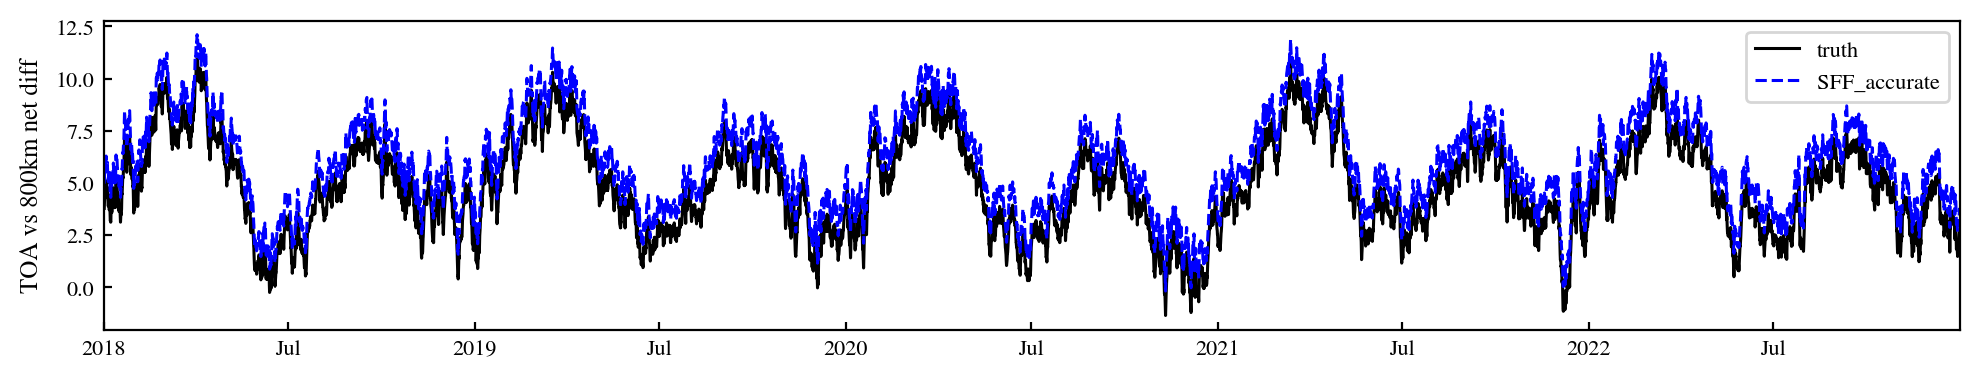

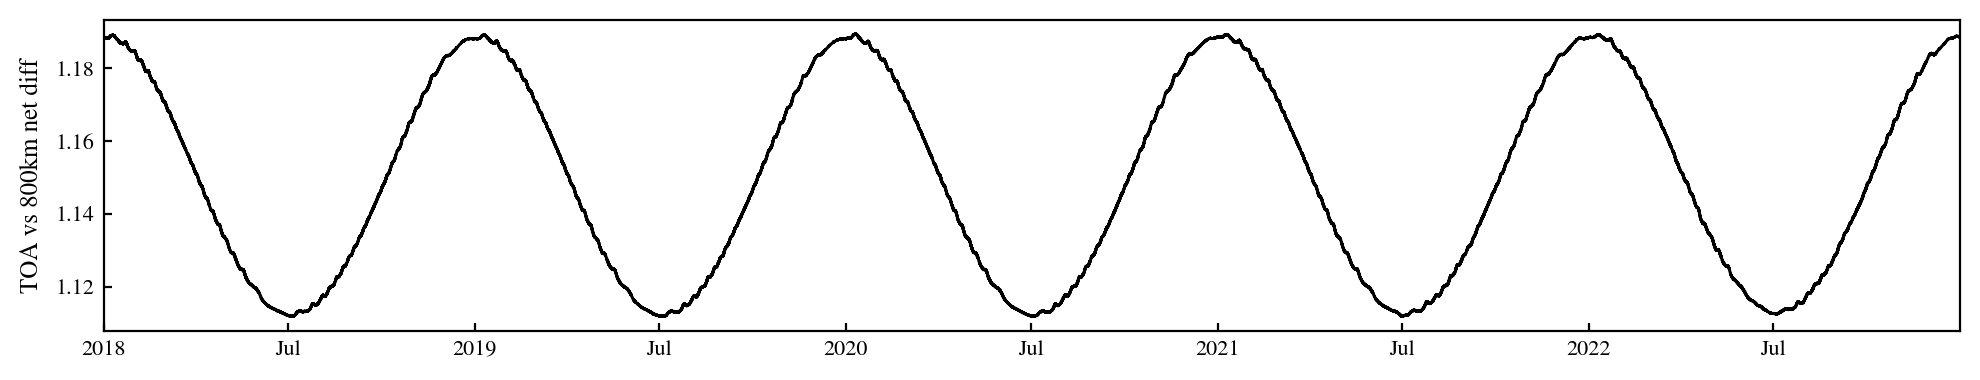

In [10]:
window = 1
full_net_alt_smooth = normal_smoother(full_net_alt, jd_array, window, out_length_mode='same_with_nans')
EEI_smooth_true = normal_smoother(EEI_true_time_series, jd_array, window_width_days=window, 
                                out_length_mode='same_with_nans')

Plotter.plot_time_series(jd_array,
                        {'truth': EEI_smooth_true,
                         'SFF_accurate': full_net_alt_smooth},
                        f_width=2.5, f_height=0.5,
                        ylabel='TOA vs 800km net diff',
                        #title=f"Error RMS: {nanrms(error)}"
                        )
Plotter.plot_time_series(jd_array,
                        {'diff': full_net_alt_smooth-EEI_smooth_true},
                        f_width=2.5, f_height=0.5,
                        ylabel='TOA vs 800km net diff',
                        #title=f"Error RMS: {nanrms(error)}"
                        )


(<Figure size 2000x400 with 1 Axes>, <Axes: ylabel='TOA vs 800km net diff'>)

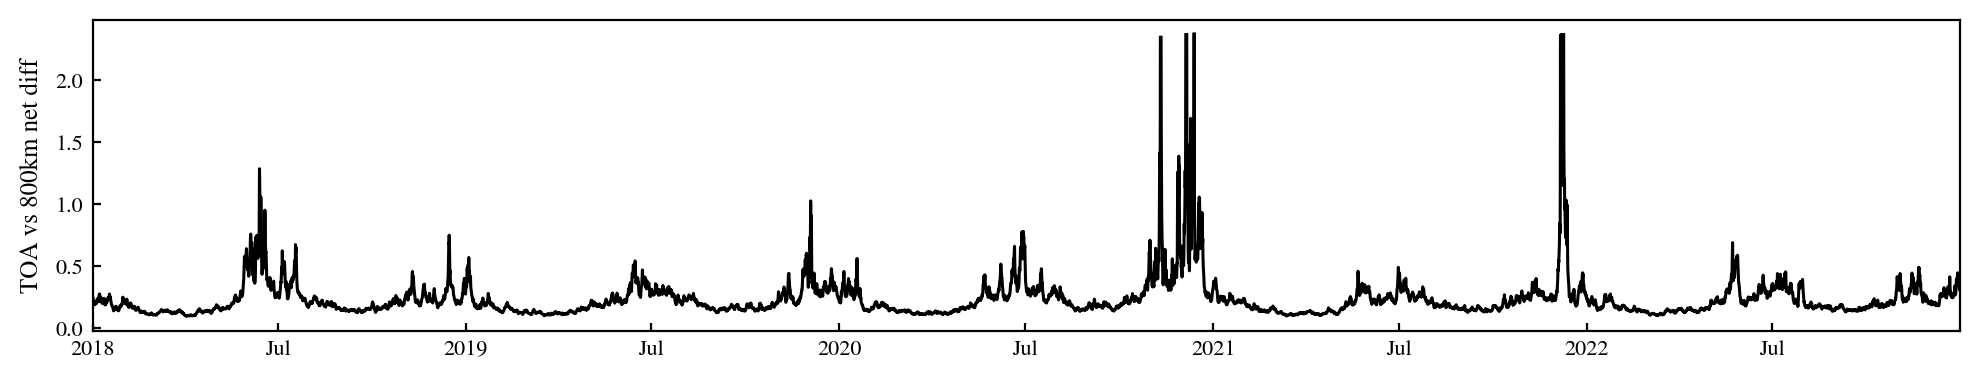

In [16]:
EEI_smooth_true_den = full_net_alt_smooth.copy()
EEI_smooth_true_den[np.abs(EEI_smooth_true_den)<5e-1] = np.nan
Plotter.plot_time_series(jd_array,
                        {'rel. diff': (full_net_alt_smooth-EEI_smooth_true)/EEI_smooth_true_den},
                        f_width=2.5, f_height=0.5,
                        ylabel='TOA vs 800km net diff',
                        #title=f"Error RMS: {nanrms(error)}"
                        )

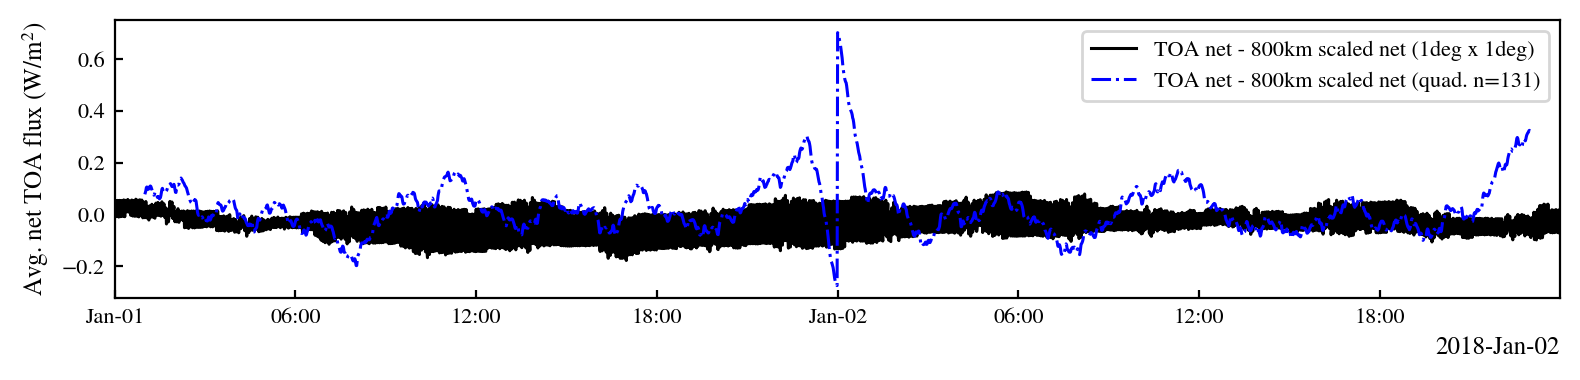

In [7]:

Plotter.plot_time_series(jd_array,
                         {'TOA net - 800km scaled net (1deg x 1deg)': toa_q131-cv800_1deg,
                          'TOA net - 800km scaled net (quad. n=131)': toa_q131 - cv800_q131_smooth,
                          },
                          f_width=2, f_height=0.5,
                          ylabel='Avg. net TOA flux (W/m$^2$)',
                          )

In [ ]:
import sys, os
import numpy as np
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import get_sphere_grid
from SpaceBalls.radiation_fluxes_preprocessing import get_file_names_and_existence
%matplotlib inline

EEI_truth_name = "EEI_truth_1"
n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
out_dir = os.path.join(MEDIA_DIR, 'true_EEI', EEI_truth_name, 'grid_'+str(n_lat)+'x'+str(n_lon))

day_idx = 0
file_names, file_existences = get_file_names_and_existence(out_dir, 800, day_idx)

true_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km']+'.npy'))
simpl_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km_simpl1']+'.npy'))

Plotter.plot_geo_data(true_avg, lon_edges_vec, lat_edges_vec, title="True Average")
Plotter.plot_geo_data(simpl_avg, lon_edges_vec, lat_edges_vec, title="Simpl Average")
Plotter.plot_geo_data(true_avg - simpl_avg, lon_edges_vec, lat_edges_vec, title="True - simpl average")

In [ ]:
true_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km_SFF']+'.npy'))
simpl_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km_simpl1_SFF']+'.npy'))

Plotter.plot_geo_data(true_avg, lon_edges_vec, lat_edges_vec, title="True Average SFF")
Plotter.plot_geo_data(simpl_avg, lon_edges_vec, lat_edges_vec, title="Simpl Average SFF")
Plotter.plot_geo_data(true_avg - simpl_avg, lon_edges_vec, lat_edges_vec, title="True - simpl average SFF",
                      max_mag=0.25)

In [ ]:
import sys, os
import numpy as np
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import get_sphere_grid
from SpaceBalls.radiation_fluxes_preprocessing import get_file_names_and_existence
%matplotlib inline

EEI_truth_name = "EEI_truth_1"
n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
out_dir = os.path.join(MEDIA_DIR, 'true_EEI', EEI_truth_name, 'grid_'+str(n_lat)+'x'+str(n_lon))

# TOA
day_idx = 0
file_names, file_existences = get_file_names_and_existence(out_dir, 800, day_idx)
#del(file_names['daily_hist_net_toa_lat_avg'])
#del(file_names['daily_hist_net_toa_surf_avg'])

for fkey, fname in file_names.items():
    print(fname)
    if file_existences[fkey]:
        try:
            map = np.load(fname+'.npy')
        except:
            map = np.loadtxt(fname+'.txt')
            if len(map)>n_lon*n_lat:
                map = map.reshape((n_lat, n_lon, 1440))

        if len(np.shape(map))==3:
            Plotter.plot_geo_data(map[:,:,0], lon_edges_vec, lat_edges_vec, title=fkey)
            Plotter.plot_geo_data(map[:,:,700], lon_edges_vec, lat_edges_vec, title=fkey)
        elif len(np.shape(map))==2 and np.shape(map)==(n_lat, n_lon):
            Plotter.plot_geo_data(map, lon_edges_vec, lat_edges_vec, title=fkey)
        else:
            print(np.shape(map))

